<a href="https://colab.research.google.com/github/royhridoy965-sketch/AI-and-ML-Lab/blob/main/CNN/CNN_RPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/royhridoy965-sketch/AI-and-ML-Lab.git

Cloning into 'AI-and-ML-Lab'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 107 (delta 21), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.04 MiB | 13.49 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [ ]:
import os

print(os.listdir("AI-and-ML-Lab/CNN"))

['dataset', 'model', 'README.md']


In [ ]:
import os

print(os.listdir("AI-and-ML-Lab/CNN/dataset"))

['scissors_04.jpeg', '.gitkeep', 'rock_04.jpeg', 'rock_02.jpeg', 'scissors_01.jpeg', 'scissors_03.jpeg', 'paper_02.jpeg', 'scissors_02.jpeg', 'paper_01.jpeg', 'rock_03.jpeg']


In [ ]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
GPU available: False


In [ ]:
import os
import zipfile
import urllib.request

# Create data folder
os.makedirs("rps_data", exist_ok=True)

# Download training dataset
train_url = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
train_zip = "rps_train.zip"

urllib.request.urlretrieve(train_url, train_zip)

# Extract training dataset
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall("rps_data")

print("RPS training dataset downloaded and extracted successfully!")

RPS training dataset downloaded and extracted successfully!


In [ ]:
import os

base_path = "rps_data/rps"

for class_name in ["rock", "paper", "scissors"]:
    class_path = os.path.join(base_path, class_name)
    images = os.listdir(class_path)
    print(f"{class_name}: {len(images)} images")

rock: 840 images
paper: 840 images
scissors: 840 images


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load RPS dataset
dataset = datasets.ImageFolder(
    root="rps_data/rps",
    transform=transform
)

# Split into training and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['paper', 'rock', 'scissors']
Total images: 2520
Training images: 2016
Validation images: 504


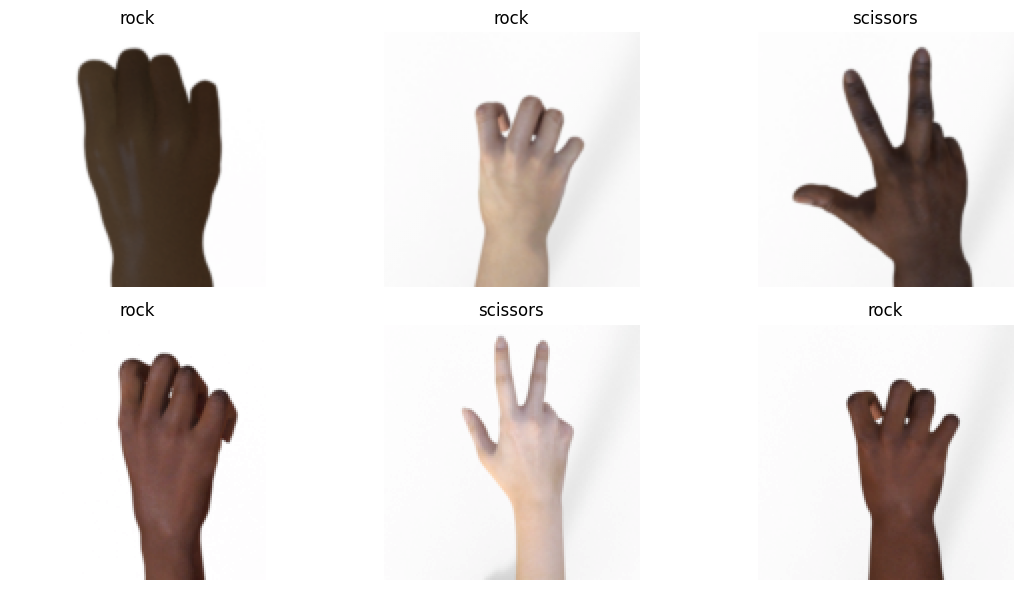

In [ ]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

# Display 6 images
plt.figure(figsize=(12, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    # Convert tensor to displayable image
    img = images[i].permute(1, 2, 0)

    # Undo normalization for visualization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    plt.imshow(img)
    plt.title(dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            # Convolution 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create model
model = CNN()

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [ ]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("Loss Function:", criterion)
print("Optimizer: Adam")

Device: cpu
Loss Function: CrossEntropyLoss()
Optimizer: Adam


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
!git clone https://github.com/royhridoy965-sketch/AI-and-ML-Lab.git

Cloning into 'AI-and-ML-Lab'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 107 (delta 21), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.04 MiB | 324.00 KiB/s, done.
Resolving deltas: 100% (21/21), done.


In [ ]:
import os

print(os.listdir("AI-and-ML-Lab/CNN"))

['model', 'README.md', 'dataset']


In [ ]:
import os
import zipfile
import urllib.request

# Create data folder
os.makedirs("rps_data", exist_ok=True)

# Download standard RPS dataset
train_url = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
train_zip = "rps_train.zip"

urllib.request.urlretrieve(train_url, train_zip)

# Extract dataset
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall("rps_data")

print("RPS training dataset downloaded and extracted successfully!")

RPS training dataset downloaded and extracted successfully!


In [ ]:
import os

base_path = "rps_data/rps"

for class_name in ["rock", "paper", "scissors"]:
    class_path = os.path.join(base_path, class_name)
    images = os.listdir(class_path)
    print(f"{class_name}: {len(images)} images")

rock: 840 images
paper: 840 images
scissors: 840 images


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load RPS dataset
dataset = datasets.ImageFolder(
    root="rps_data/rps",
    transform=transform
)

# Split: 80% training, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['paper', 'rock', 'scissors']
Total images: 2520
Training images: 2016
Validation images: 504


In [ ]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            # Convolution 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create model
model = CNN()

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [ ]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to GPU
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Loss Function:", criterion)
print("Optimizer: Adam")

Device: cuda
GPU: Tesla T4
Loss Function: CrossEntropyLoss()
Optimizer: Adam


In [ ]:
# Number of epochs
num_epochs = 10

# Store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # =========================
    # Validation
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] | Train Loss: 1.0394 | Train Acc: 56.94% | Val Loss: 0.3519 | Val Acc: 87.50%
Epoch [2/10] | Train Loss: 0.1166 | Train Acc: 96.73% | Val Loss: 0.0420 | Val Acc: 98.61%
Epoch [3/10] | Train Loss: 0.0109 | Train Acc: 99.65% | Val Loss: 0.0041 | Val Acc: 100.00%
Epoch [4/10] | Train Loss: 0.0015 | Train Acc: 100.00% | Val Loss: 0.0014 | Val Acc: 100.00%
Epoch [5/10] | Train Loss: 0.0005 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 100.00%
Epoch [6/10] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0004 | Val Acc: 100.00%
Epoch [7/10] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0003 | Val Acc: 100.00%
Epoch [8/10] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [9/10] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [10/10] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0002 | Val Acc: 100.00%


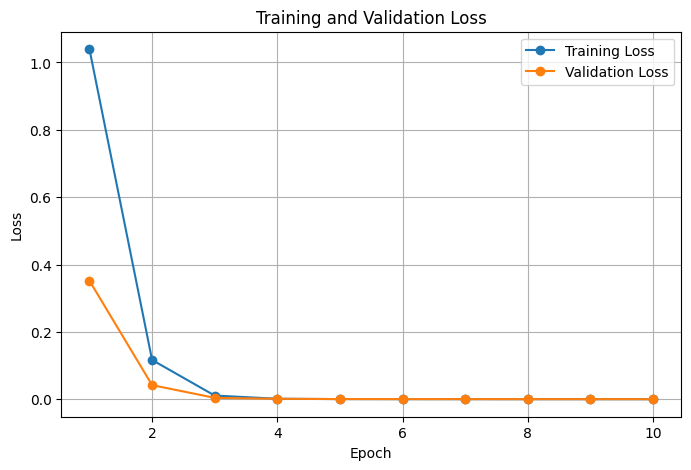

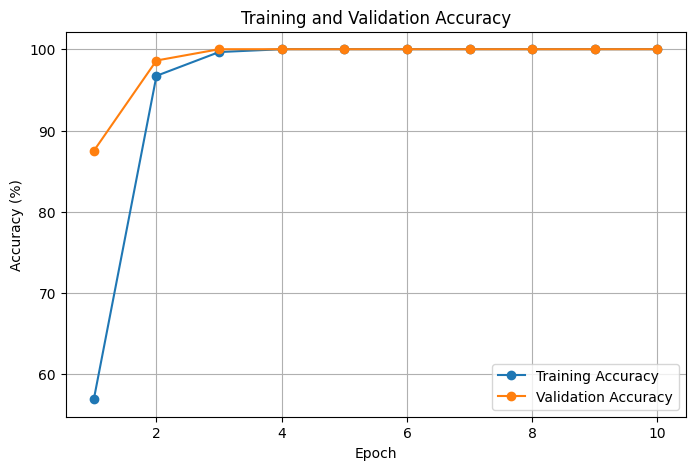

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# =========================
# Loss Graph
# =========================
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


# =========================
# Accuracy Graph
# =========================
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Save trained model state dictionary

model_path = "AI-and-ML-Lab/CNN/model/CNN_RPS.pth"

torch.save(model.state_dict(), model_path)

print("Model saved successfully!")
print("Saved at:", model_path)

Model saved successfully!
Saved at: AI-and-ML-Lab/CNN/model/CNN_RPS.pth


In [ ]:
import os

model_path = "AI-and-ML-Lab/CNN/model/CNN_RPS.pth"

if os.path.exists(model_path):
    print("Model file found!")
    print("File size:", os.path.getsize(model_path) / (1024 * 1024), "MB")
else:
    print("Model file not found!")

Model file found!
File size: 16.361454963684082 MB


In [ ]:
from google.colab import files

files.download("AI-and-ML-Lab/CNN/model/CNN_RPS.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Put model in evaluation mode
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


# Calculate evaluation metrics
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


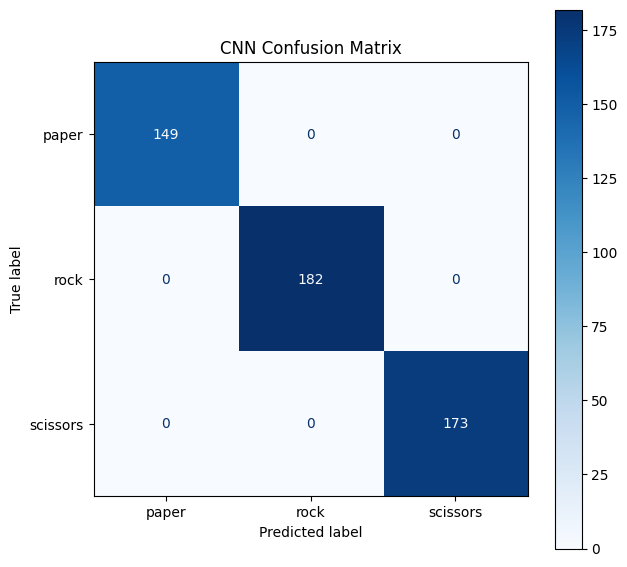

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

       paper     1.0000    1.0000    1.0000       149
        rock     1.0000    1.0000    1.0000       182
    scissors     1.0000    1.0000    1.0000       173

    accuracy                         1.0000       504
   macro avg     1.0000    1.0000    1.0000       504
weighted avg     1.0000    1.0000    1.0000       504



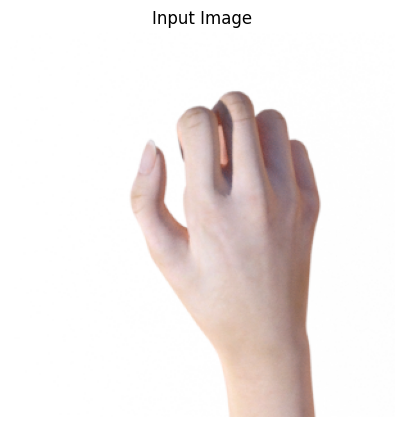

Actual class: rock
Predicted class: rock


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Take one image from the dataset
image_path = "rps_data/rps/rock/rock01-000.png"

# Open image
image = Image.open(image_path).convert("RGB")

# Show image
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Apply preprocessing
input_image = transform(image).unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():
    output = model(input_image)
    _, predicted = torch.max(output, 1)

predicted_class = dataset.classes[predicted.item()]

print("Actual class: rock")
print("Predicted class:", predicted_class)

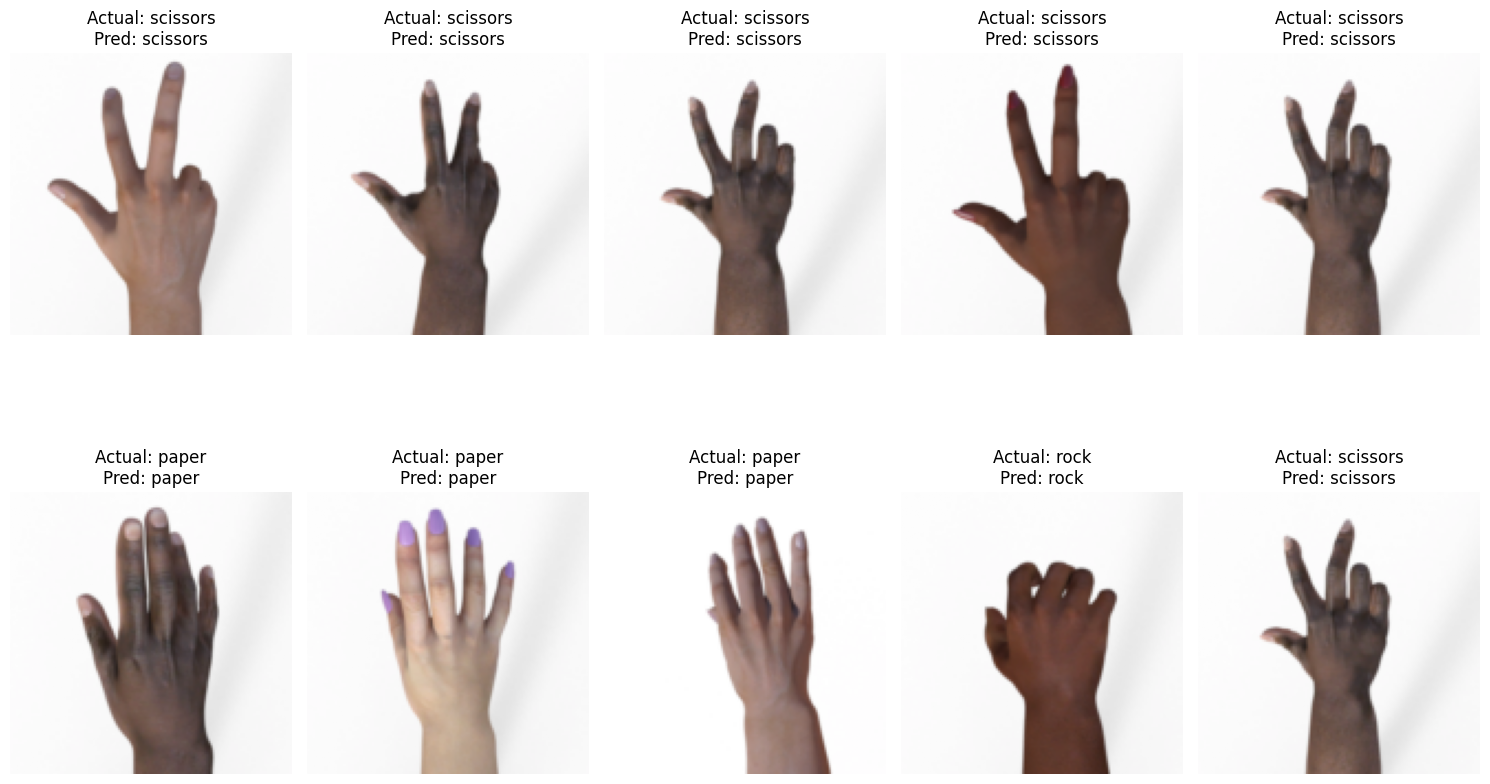

Correct predictions: 10/10
Sample accuracy: 100.00%


In [ ]:
import random
import matplotlib.pyplot as plt

# Select 10 random validation images
samples = random.sample(range(len(val_dataset)), 10)

plt.figure(figsize=(15, 10))

correct_count = 0

for i, idx in enumerate(samples):

    image_tensor, label = val_dataset[idx]

    # Add batch dimension and move to device
    input_image = image_tensor.unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(input_image)
        _, predicted = torch.max(output, 1)

    actual_class = dataset.classes[label]
    predicted_class = dataset.classes[predicted.item()]

    if actual_class == predicted_class:
        correct_count += 1

    # Display image
    image_display = image_tensor.cpu()

    # Undo normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image_display = image_display * std + mean
    image_display = torch.clamp(image_display, 0, 1)

    image_display = image_display.permute(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image_display)
    plt.title(
        f"Actual: {actual_class}\nPred: {predicted_class}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Correct predictions: {correct_count}/10")
print(f"Sample accuracy: {correct_count/10*100:.2f}%")

Total custom images: 10


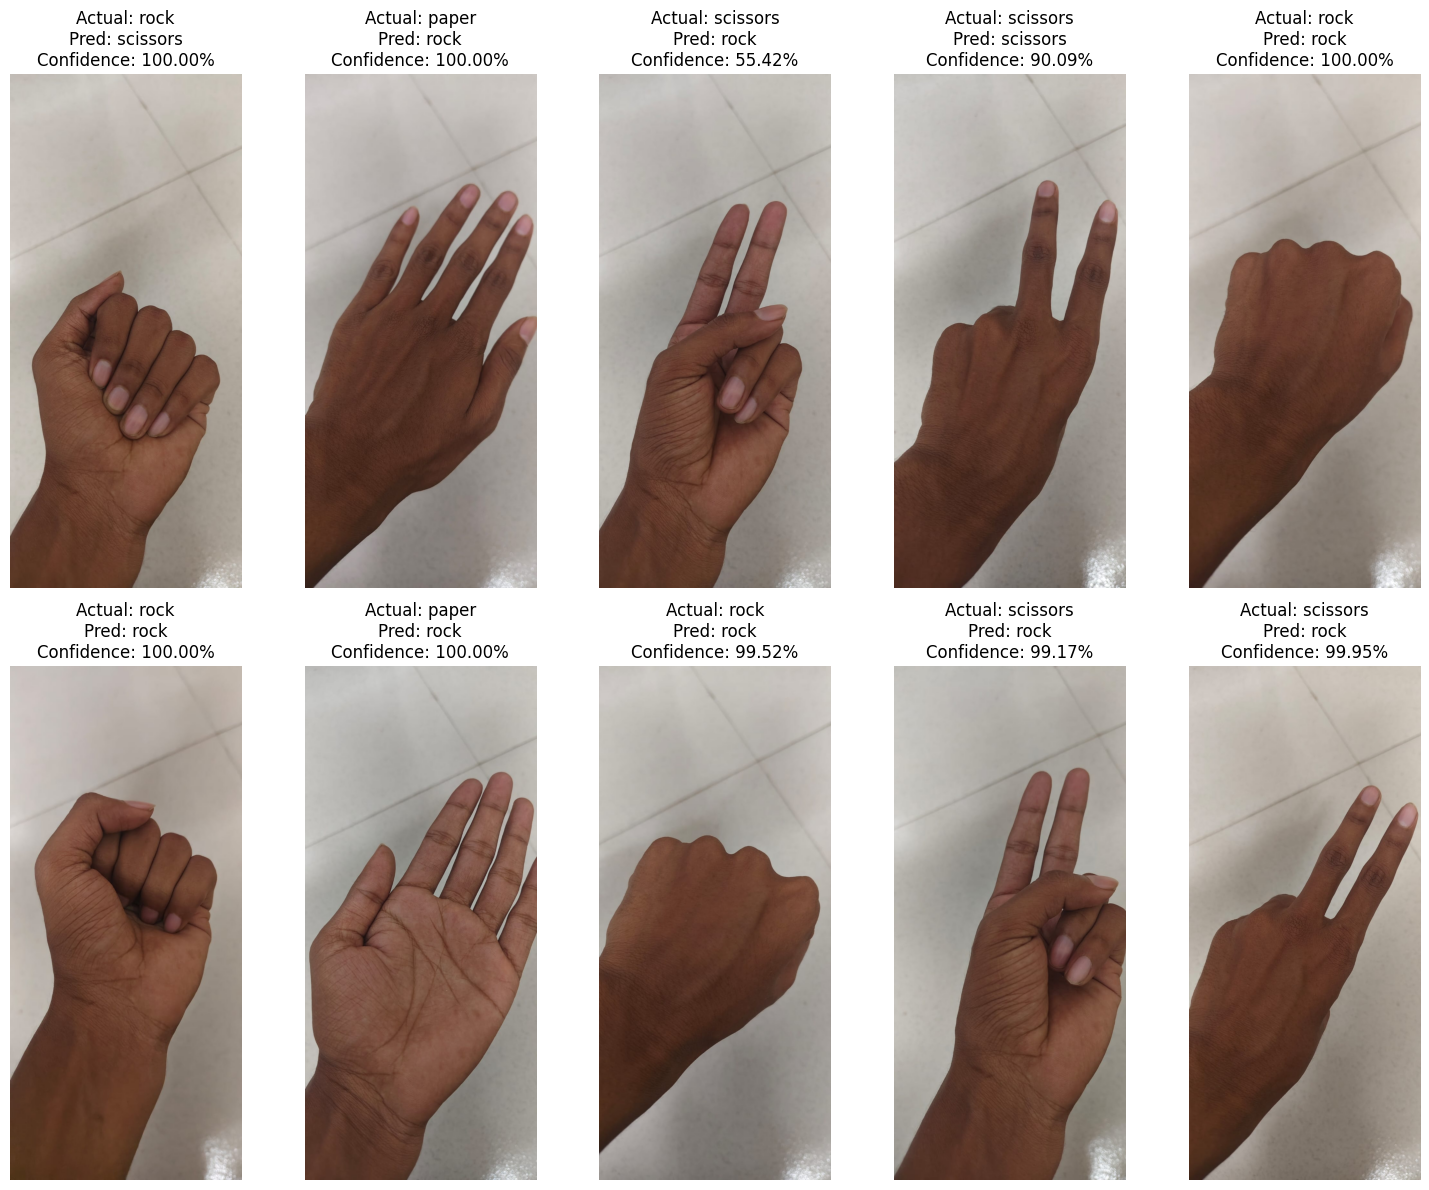

Correct predictions: 4/10
Custom image accuracy: 40.00%


In [26]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Path to our 10 custom images
custom_path = "AI-and-ML-Lab/CNN/dataset"

# Get all image files
image_paths = glob.glob(os.path.join(custom_path, "*.jpg"))
image_paths += glob.glob(os.path.join(custom_path, "*.jpeg"))
image_paths += glob.glob(os.path.join(custom_path, "*.png"))

print("Total custom images:", len(image_paths))

# Prediction
model.eval()

correct_count = 0

plt.figure(figsize=(15, 12))

for i, image_path in enumerate(image_paths):

    image = Image.open(image_path).convert("RGB")

    # Preprocessing
    input_image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_image)

        # Convert output to probabilities
        probabilities = torch.softmax(output, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = dataset.classes[predicted.item()]
    confidence_value = confidence.item() * 100

    # Actual class from filename
    filename = os.path.basename(image_path)
    actual_class = filename.split("_")[0]

    # Check whether prediction is correct
    if actual_class == predicted_class:
        correct_count += 1

    # Display
    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual_class}\n"
        f"Pred: {predicted_class}\n"
        f"Confidence: {confidence_value:.2f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Final custom image result
print(f"Correct predictions: {correct_count}/{len(image_paths)}")
print(
    f"Custom image accuracy: "
    f"{correct_count / len(image_paths) * 100:.2f}%"
)

In [24]:
import shutil

shutil.move(
    "/content/rock_01.jpeg",
    "/content/AI-and-ML-Lab/CNN/dataset/rock_01.jpeg"
)

print("rock_01.jpeg moved successfully!")

rock_01.jpeg moved successfully!
